In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/loan-approval-dataset/loan_approval.csv


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the data set 
df=pd.read_csv('/kaggle/input/loan-approval-dataset/loan_approval.csv')
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


In [18]:
# Checking the null values 
df.isna().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [19]:
# duplicate values
df.duplicated().sum()

0

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   object 
 1   city            2000 non-null   object 
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), object(2)
memory usage: 111.5+ KB


In [21]:
df.shape

(2000, 8)

In [22]:
# Checking whether the output variable is balanced or imbalanced.
df.loan_approved.value_counts()

loan_approved
False    1121
True      879
Name: count, dtype: int64

## ANN Model Implementation.
- It’s a balanced data set,so we will focus on the accuracy score rather than the F1 score.
- For the ANN architecture, download libraries such as Sequential, Dense, ReLU, Adam, etc.
- For the ANN, we definitely need to scale both the X_test and X_train data.
- Since this is a binary classification problem, we will use the sigmoid function as the output activation function.
- Compile the model for 30 epochs and add an early stopping function to halt training before completing all epochs once a good score is achieved.


In [23]:
# Import the necessary libraries for constructing the artificial neural network (ANN) model.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report,confusion_matrix
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import ReLU,LeakyReLU
from keras.layers import Dropout
from keras.callbacks import EarlyStopping


# Split the data into dependent and independent variables

X=df.iloc[:,2:7]

y=df.iloc[:,7]

# split the data into train test data

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

# For the ANN model, scaling the data is required

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)


# Designing the architecture of the artificial neural network (ANN)

# Initialise the model, it does forward and backward propagation
ann_model=Sequential()

''''
The first input layer, with 5 units, represents the input variables. 
 In simple terms, how many x columns have we used for these units?
'''
ann_model.add(Dense(units=5,activation='relu'))

'''
 We can utilise multiple hidden layers in our ANN architecture, but in this instance, 
 I chose to include just two hidden layers. For the first hidden layer, 
 I set the number of neurons to 10, and for the second hidden layer, 
 I chose 15 neurons. The selection of neurons can vary based on our preferences and 
 the specific problem at hand. I opted for the ReLU activation function for each of these layers, 
 as it tends to perform well in practice compared to other activation functions. 
 Different activation functions are available, but ReLU has demonstrated effectiveness for this particular problem.

'''
ann_model.add(Dense(units=10,activation='relu'))
#Add dropout
ann_model.add(Dropout(0.3))

# Second hidden layer.
ann_model.add(Dense(units=15,activation='relu'))
ann_model.add(Dropout(0.4))

'''
In the output layer, I specified that 1 is my output, and I used the sigmoid activation function. 
This setup indicates that it's a binary classification problem, 
and the sigmoid activation is well-suited for such cases. 
I also implemented an early stopping function to monitor the training process and prevent overfitting, 
which helped achieve a good accuracy score. For optimisation, I chose the Adam optimiser, 
as it's considered one of the best options for this type of task.

'''
ann_model.add(Dense(units=1,activation='sigmoid'))

# Compile the model
ann_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

# Early stopping function
early_stopping = EarlyStopping(
        monitor='val_loss', 
        min_delta=1,        
        patience=4,       
        verbose=1,       
        mode='min',
        restore_best_weights=True
    )


# fit the model with the train and test datasets and add the early stopping function

model_fit=ann_model.fit(X_train,y_train,validation_split=0.25,epochs=25,batch_size=20,callbacks=early_stopping)
model_history=model_fit.history

Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.5718 - loss: 0.6822 - val_accuracy: 0.7387 - val_loss: 0.6132
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6975 - loss: 0.5959 - val_accuracy: 0.8427 - val_loss: 0.5052
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7809 - loss: 0.5075 - val_accuracy: 0.8853 - val_loss: 0.3758
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8406 - loss: 0.3942 - val_accuracy: 0.9307 - val_loss: 0.2666
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8899 - loss: 0.3010 - val_accuracy: 0.9467 - val_loss: 0.1879
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


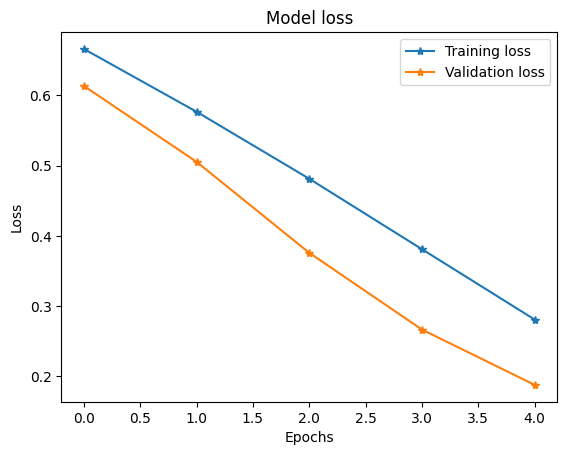

In [24]:
# plot the loss in each epoch 
plt.plot(model_history['loss'],marker='*')
plt.plot(model_history['val_loss'],marker='*')
plt.title("Model loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(["Training loss", "Validation loss"])
plt.show()

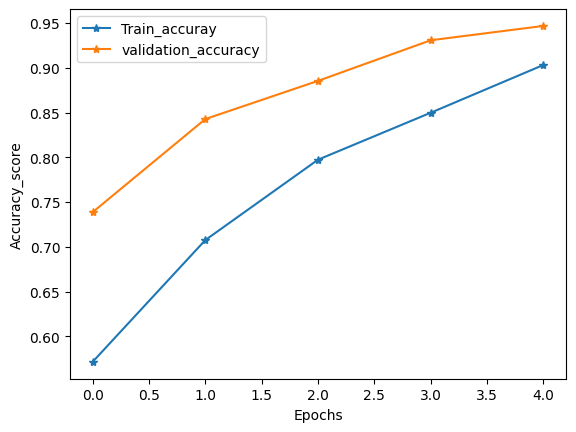

In [25]:
# Accuracy plot in each epoch

plt.plot(model_history['accuracy'],marker='*')
plt.plot(model_history['val_accuracy'],marker='*')
plt.xlabel("Epochs")
plt.ylabel("Accuracy_score")
plt.legend(['Train_accuray',"validation_accuracy"])
plt.show()

In [26]:
# Prediction of the unseen data
y_pred=ann_model.predict(X_test)
y_pred=y_pred >=0.5

# In the confusion matrix, since we have a balanced dataset, we focus on the accuracy score.
matrix=confusion_matrix(y_test,y_pred)

matrix


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


array([[229,  49],
       [ 67, 155]])

In [27]:
# Classification report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.77      0.82      0.80       278
        True       0.76      0.70      0.73       222

    accuracy                           0.77       500
   macro avg       0.77      0.76      0.76       500
weighted avg       0.77      0.77      0.77       500



## Conclusion:
We built a simple artificial neural network (ANN) for a binary classification problem. Our primary focus was on achieving a high accuracy score. The dataset we used was relatively small, consisting of only 2,000 values. We achieved an accuracy score of 94% with our model.
